In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


df = sns.load_dataset("taxis")

print("Missing values before imputation:\n", df.isnull().sum())

for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object', 'category']).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

df = df.dropna()

print("\nMissing values after handling:\n", df.isnull().sum())

Missing values before imputation:
 pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

Missing values after handling:
 pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


C:\Users\Mohammed K\AppData\Local\Temp\ipykernel_15920\3781373361.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object', 'category']).columns:


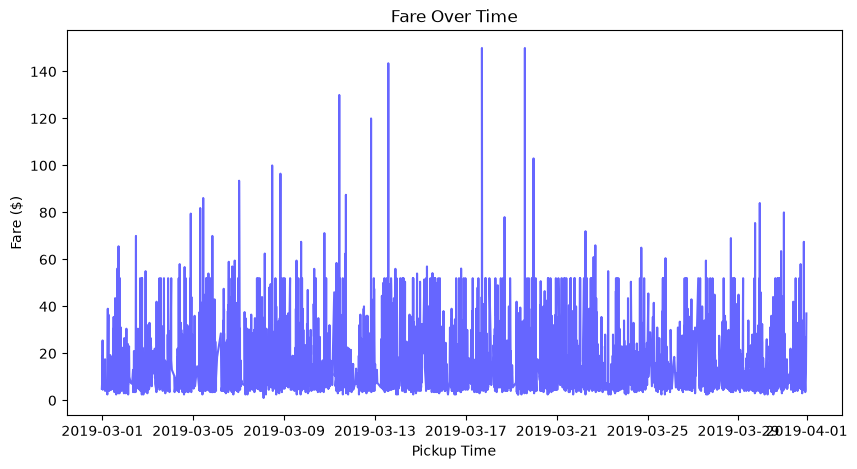

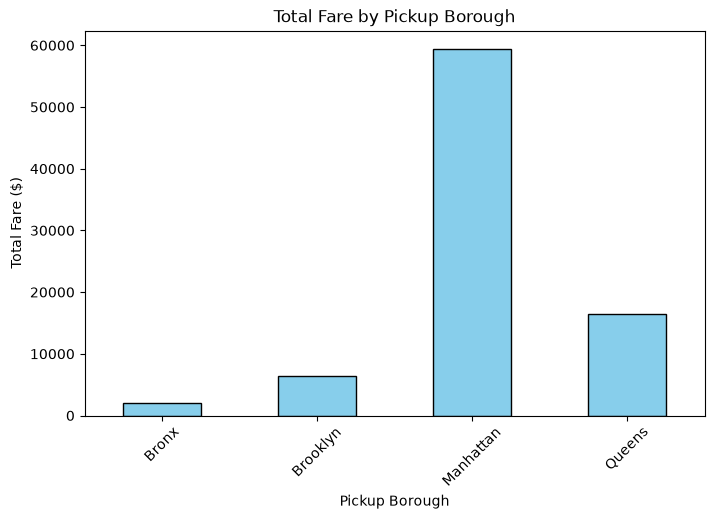

In [3]:
df['pickup'] = pd.to_datetime(df['pickup'])
df_sorted = df.sort_values('pickup')

plt.figure(figsize=(10, 5))
plt.plot(df_sorted['pickup'], df_sorted['fare'], color='blue', alpha=0.6)
plt.title('Fare Over Time')
plt.xlabel('Pickup Time')
plt.ylabel('Fare ($)')
plt.show()

total_fare_borough = df.groupby('pickup_borough')['fare'].sum()

plt.figure(figsize=(8, 5))
total_fare_borough.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Fare by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare ($)')
plt.xticks(rotation=45)
plt.show()

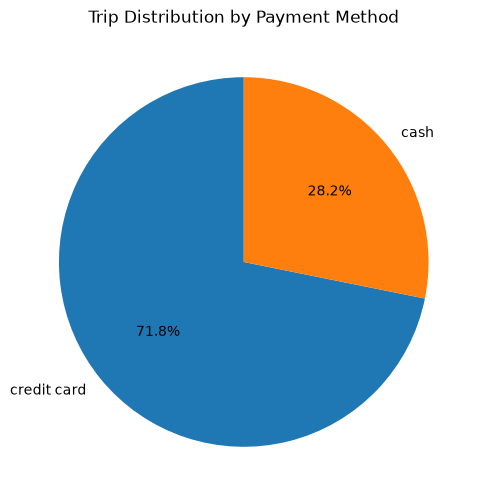

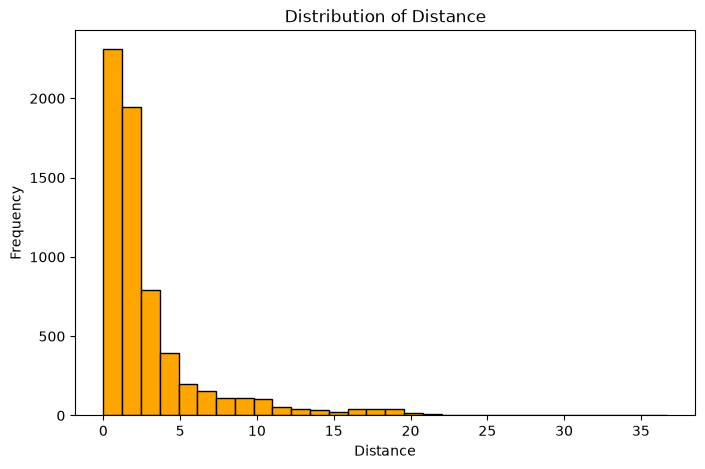

In [4]:
payment_counts = df['payment'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Trip Distribution by Payment Method')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['distance'], bins=30, color='orange', edgecolor='black')
plt.title('Distribution of Distance')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.show()

C:\Users\Mohammed K\AppData\Local\Temp\ipykernel_15920\2336046106.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pickup_borough', y='tip', palette='Set2')


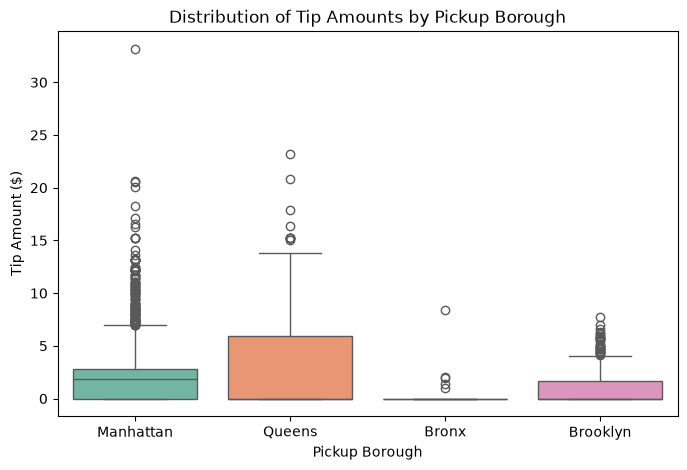

C:\Users\Mohammed K\AppData\Local\Temp\ipykernel_15920\2336046106.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pickup_borough', palette='Set1')


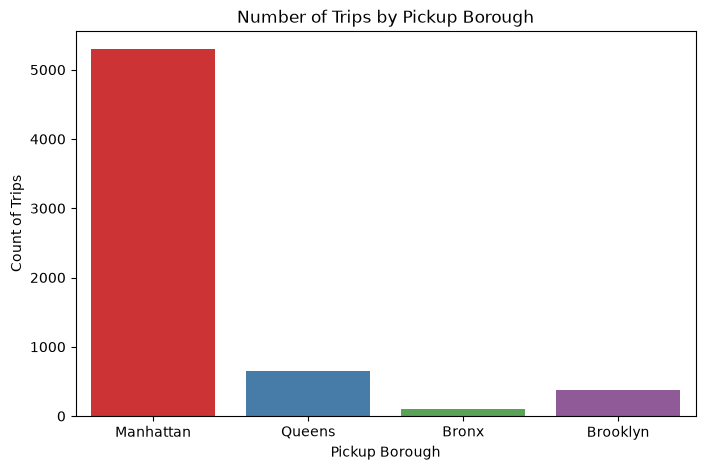

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='pickup_borough', y='tip', palette='Set2')
plt.title('Distribution of Tip Amounts by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount ($)')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='pickup_borough', palette='Set1')
plt.title('Number of Trips by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Count of Trips')
plt.show()

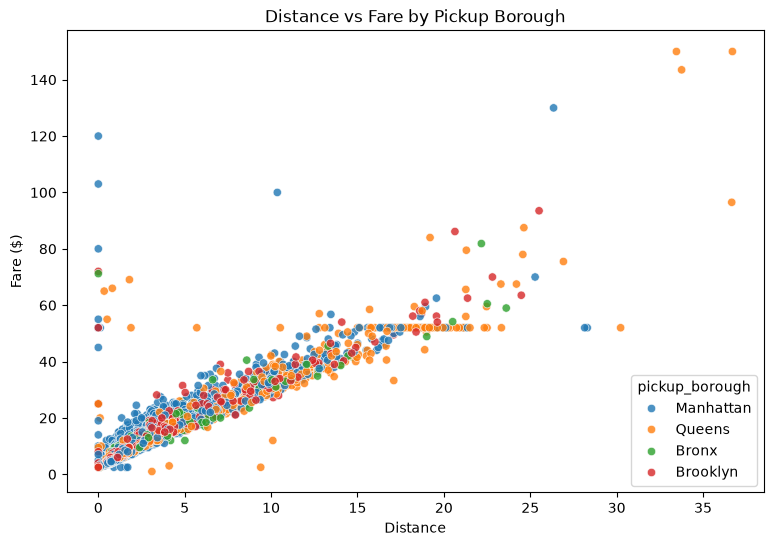

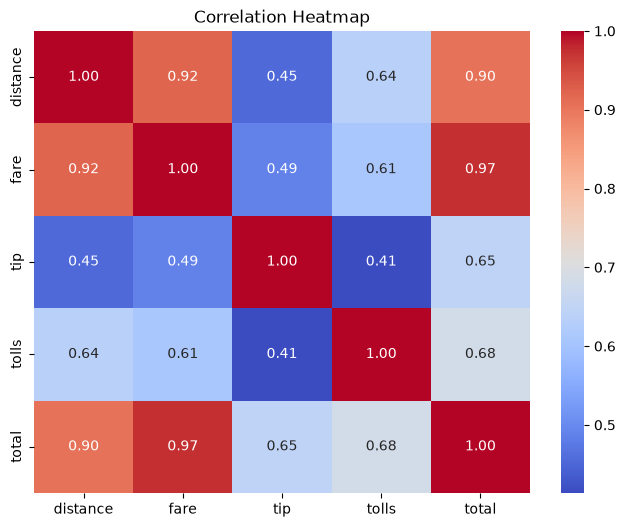

In [6]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='distance', y='fare', hue='pickup_borough', alpha=0.8)
plt.title('Distance vs Fare by Pickup Borough')
plt.xlabel('Distance')
plt.ylabel('Fare ($)')
plt.show()

plt.figure(figsize=(8, 6))
num_cols = ['distance', 'fare', 'tip', 'tolls', 'total']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

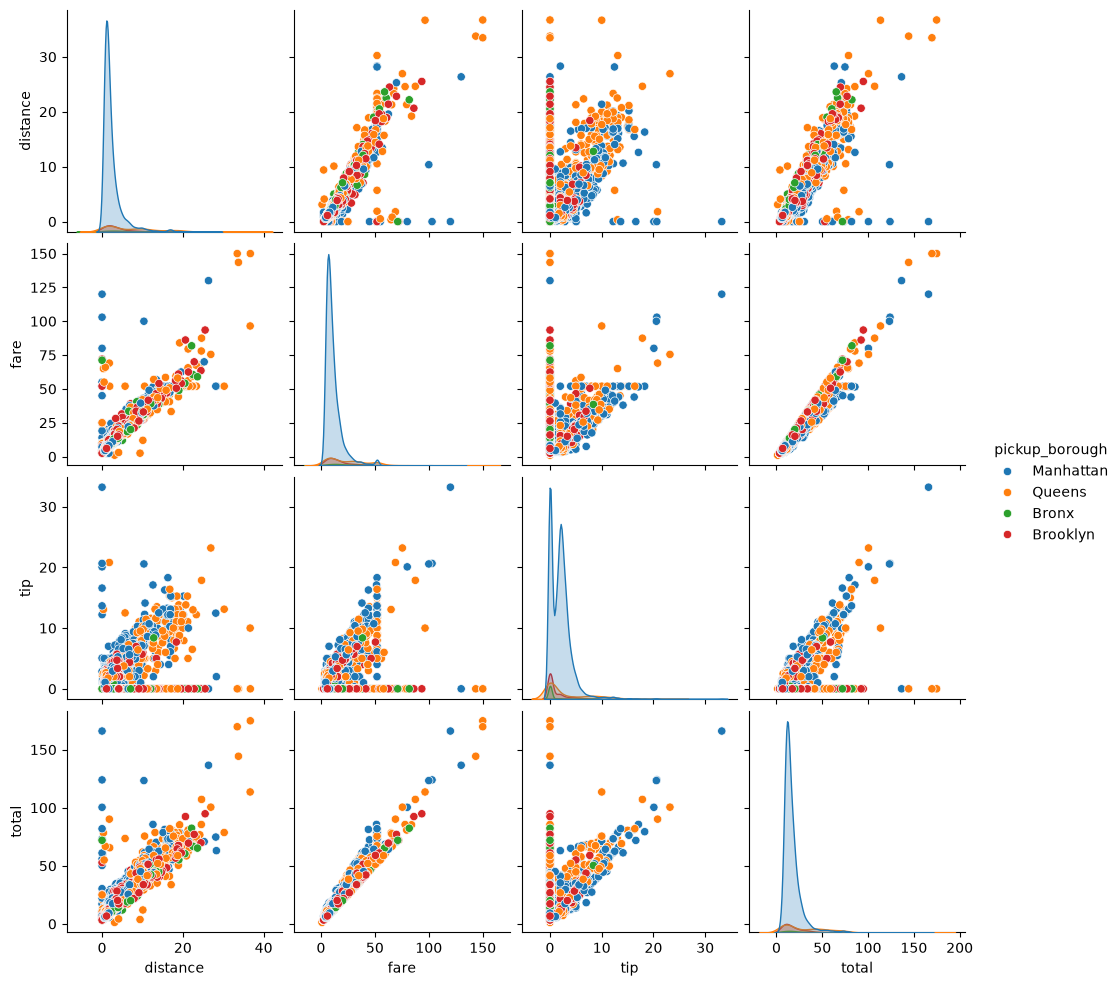

C:\Users\Mohammed K\AppData\Local\Temp\ipykernel_15920\3203944630.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='payment', y='fare', palette='muted')


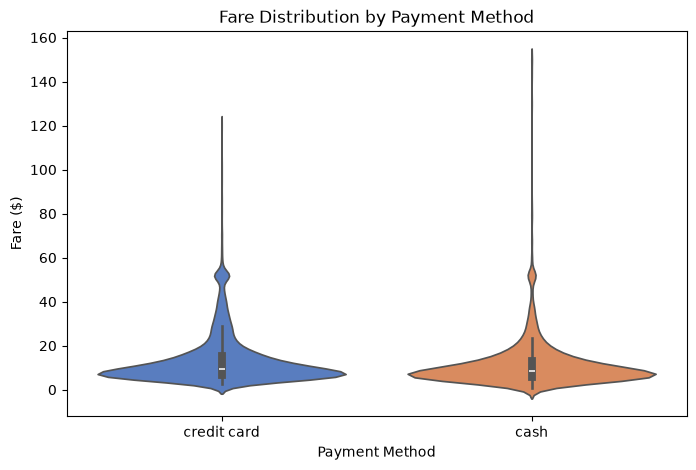

In [10]:
sns.pairplot(df[['distance', 'fare', 'tip', 'total', 'pickup_borough']], hue='pickup_borough')
plt.show()

plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='payment', y='fare', palette='muted')
plt.title('Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare ($)')
plt.show()